Para este ejemplo, utilizaremos la base de datos **'Adult'** (también conocida como 'Census Income Dataset') de la librería de `sklearn`, que contiene tanto características numéricas como categóricas, y la tarea será predecir si una persona gana más o menos de $50K al año. Realizaremos una búsqueda de hiperparámetros usando **GridSearchCV** y **Optuna** para **XGBoost**, **CatBoost** y **LightGBM**, compararemos los resultados y analizaremos la importancia de las características de cada modelo.



### Pasos a seguir:
1. Cargar y preprocesar los datos.
2. Crear pipelines para el preprocesamiento de datos categóricos y numéricos.
3. Entrenar los modelos de **XGBoost**, **CatBoost** y **LightGBM**.
4. Realizar búsqueda de hiperparámetros con **GridSearchCV** y **Optuna**.
5. Evaluar los modelos y comparar el rendimiento.
6. Analizar e interpretar la **importancia de características**.



### Paso 1: Cargar y preprocesar los datos


In [ ]:
# Instalar Optuna
!pip install optuna

# Instalar CatBoost
!pip install catboost

# Instalar LightGBM
!pip install lightgbm

# Instalar XGBoost
!pip install xgboost



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.8/362.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.2/233.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 5.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Cargar dataset Adult de sklearn
data = fetch_openml(data_id=1590, as_frame=True)
df = data.frame

# Separar características y etiquetas
X = df.drop(columns='class')
y = df['class']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Identificar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=['category', 'object']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns


### Paso 2: Crear pipelines para el preprocesamiento


In [ ]:
# Preprocesamiento de variables categóricas y numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])




### Paso 3: Entrenar los modelos con **XGBoost**, **CatBoost** y **LightGBM**


In [ ]:
# Pipeline general que incluirá el preprocesamiento y el modelo

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Definir modelos
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
cat_model = CatBoostClassifier(silent=True)
lgbm_model = LGBMClassifier()

# Crear pipelines con preprocesamiento y modelo
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_model)])
cat_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', cat_model)])
lgbm_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', lgbm_model)])


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)



### Paso 4: Búsqueda de hiperparámetros con **GridSearchCV**


In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir hiperparámetros para búsqueda
xgb_params = {
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__max_depth': [3, 6],
    'classifier__n_estimators': [100, 200]
}

lgbm_params = {
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__num_leaves': [31, 50],
    'classifier__n_estimators': [100, 200]
}

cat_params = {
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__depth': [3, 6],
    'classifier__iterations': [100, 200]
}


In [ ]:
from sklearn.preprocessing import LabelEncoder


# Grid Search
xgb_grid = GridSearchCV(xgb_pipeline, xgb_params, cv=3, n_jobs=-1, scoring='accuracy')
lgbm_grid = GridSearchCV(lgbm_pipeline, lgbm_params, cv=3, n_jobs=-1, scoring='accuracy')
cat_grid = GridSearchCV(cat_pipeline, cat_params, cv=3, n_jobs=-1, scoring='accuracy')

# Create a LabelEncoder object
le = LabelEncoder()

# Fit the encoder to your target variable and transform it
y_train = le.fit_transform(y_train)


# Entrenar con Grid Search
xgb_grid.fit(X_train, y_train)
lgbm_grid.fit(X_train, y_train)
cat_grid.fit(X_train, y_train)



# Mejor modelo y puntajes
print("Mejor modelo XGBoost:", xgb_grid.best_params_, "Acc:", xgb_grid.best_score_)
print("Mejor modelo LightGBM:", lgbm_grid.best_params_, "Acc:", lgbm_grid.best_score_)
print("Mejor modelo CatBoost:", cat_grid.best_params_, "Acc:", cat_grid.best_score_)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [20:20:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 8267, number of negative: 25922
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016403 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 792
[LightGBM] [Info] Number of data points in the train set: 34189, number of used features: 97
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.241803 -> initscore=-1.142820
[LightGBM] [Info] Start training from score -1.142820
Mejor modelo XGBoost: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 200} Acc: 0.8710989271663134
Mejor modelo LightGBM: {'classifier__learning_rate': 0.1, 'classifier__n_estimators': 100, 'classifier__num_leaves': 31} Acc: 0.8696656731665945
Mejor modelo CatBoost: {'classifier__depth': 6, 'classifier__iterations': 200, 'classifier__learning_rate': 0.1} Acc: 0.870660153629356


In [ ]:
import optuna
from sklearn.metrics import accuracy_score

y_test = le.fit_transform(y_test)

# Definir función objetivo para XGBoost
def objective_xgb(trial):
    # Definir el conjunto de hiperparámetros a explorar
    param = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }

    # Crear el pipeline con el modelo XGBoost
    xgb_model.set_params(**param)
    xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_model)])

    # Entrenar y predecir
    xgb_pipeline.fit(X_train, y_train)
    y_pred = xgb_pipeline.predict(X_test)

    # Calcular y devolver la métrica de evaluación
    return accuracy_score(y_test, y_pred)

# Crear el estudio de Optuna para XGBoost
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=10)
print("Mejores hiperparámetros con Optuna para XGBoost:", study_xgb.best_params)


[I 2024-10-21 20:25:25,632] A new study created in memory with name: no-name-958716ad-d853-4eea-b7de-77e6f98a7ab0
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [20:25:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
[I 2024-10-21 20:25:32,655] Trial 0 finished with value: 0.8799563229372824 and parameters: {'learning_rate': 0.07818254639569111, 'max_depth': 6, 'n_estimators': 180, 'subsample': 0.8507507858822823, 'colsample_bytree': 0.6518808295338981}. Best is trial 0 with value: 0.8799563229372824.
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [20:25:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
[I 2024-10-21 20:25:33,214] Trial 1 finished with value: 0.8637139152392002 and parameters: {'learning_rate': 0.03256492607731788, 'max_depth': 3, 'n_estimators': 118, 'sub

Mejores hiperparámetros con Optuna para XGBoost: {'learning_rate': 0.07874834536141763, 'max_depth': 5, 'n_estimators': 182, 'subsample': 0.8888803504637086, 'colsample_bytree': 0.8995457464614393}


In [ ]:
# Obtener los mejores hiperparámetros encontrados por Optuna
best_xgb_params = study_xgb.best_params

# Crear el modelo con los mejores hiperparámetros
xgb_best_model = XGBClassifier(
    learning_rate=best_xgb_params['learning_rate'],
    max_depth=best_xgb_params['max_depth'],
    n_estimators=best_xgb_params['n_estimators'],
    subsample=best_xgb_params['subsample'],
    colsample_bytree=best_xgb_params['colsample_bytree'],
    use_label_encoder=False,
    eval_metric='logloss'
)

# Crear pipeline con preprocesamiento y el modelo final
xgb_pipeline_final = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_best_model)])

# Entrenar el modelo final en todo el conjunto de entrenamiento
xgb_pipeline_final.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_final = xgb_pipeline_final.predict(X_test)

# Evaluar el rendimiento del modelo final
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Precisión del modelo final XGBoost: {final_accuracy}")


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [20:29:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Precisión del modelo final XGBoost: 0.8813212311472054


Podemos especificar apenas un rango de parametros y no una lista puntual de hiperparámetros.

In [ ]:
import optuna
from sklearn.metrics import accuracy_score

# Definir función objetivo para XGBoost sin definir rangos estrictos de hiperparámetros
def objective_xgb(trial):
    # Optuna sugiere hiperparámetros dentro de un rango amplio, sin un conjunto predefinido de valores.
    param = {
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 1e-1),  # Búsqueda en un rango logarítmico amplio
        'max_depth': trial.suggest_int('max_depth', 2, 12),                      # Búsqueda en un rango de valores enteros
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),               # Búsqueda entre un número más amplio de estimadores
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),               # Búsqueda en un rango continuo de subsample
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0), # Búsqueda continua para fracción de características
        'gamma': trial.suggest_loguniform('gamma', 1e-8, 1.0),                   # Regularización gamma en un rango amplio
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 1.0),           # Regularización L1
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 1.0)          # Regularización L2
    }

    # Crear el modelo XGBoost con los parámetros sugeridos
    xgb_model.set_params(**param)
    xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_model)])

    # Entrenar y predecir
    xgb_pipeline.fit(X_train, y_train)
    y_pred = xgb_pipeline.predict(X_test)

    # Calcular y devolver la métrica de evaluación (en este caso, accuracy)
    return accuracy_score(y_test, y_pred)

# Crear el estudio de Optuna
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=10)  # Definir el número de pruebas (trials)

# Imprimir los mejores hiperparámetros encontrados por Optuna
print("Mejores hiperparámetros con Optuna para XGBoost:", study_xgb.best_params)


[I 2024-10-21 20:40:38,212] A new study created in memory with name: no-name-cb296c45-7ac2-41b1-9eba-9585320b5c33
<ipython-input-16-a0effd7dbcb3>:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 1e-1),  # Búsqueda en un rango logarítmico amplio
<ipython-input-16-a0effd7dbcb3>:11: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),               # Búsqueda en un rango continuo de subsample
<ipython-input-16-a0effd7dbcb3>:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/ta

Mejores hiperparámetros con Optuna para XGBoost: {'learning_rate': 0.05560844594577605, 'max_depth': 6, 'n_estimators': 276, 'subsample': 0.6272491729552803, 'colsample_bytree': 0.659467923387904, 'gamma': 0.3756565429944341, 'reg_alpha': 0.038586725826571695, 'reg_lambda': 3.568561900109699e-07}



# Repetir el proceso para CatBoost y LightGBM

Este será uno de los ejercicios de la semana.


### Paso 6: Evaluación y análisis de **Feature Importance**


In [ ]:
# Obtener el nombre de las columnas procesadas después del preprocesamiento
# Este paso es importante porque el preprocesador puede cambiar la cantidad de columnas
processed_columns = np.hstack([numeric_cols, preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)])


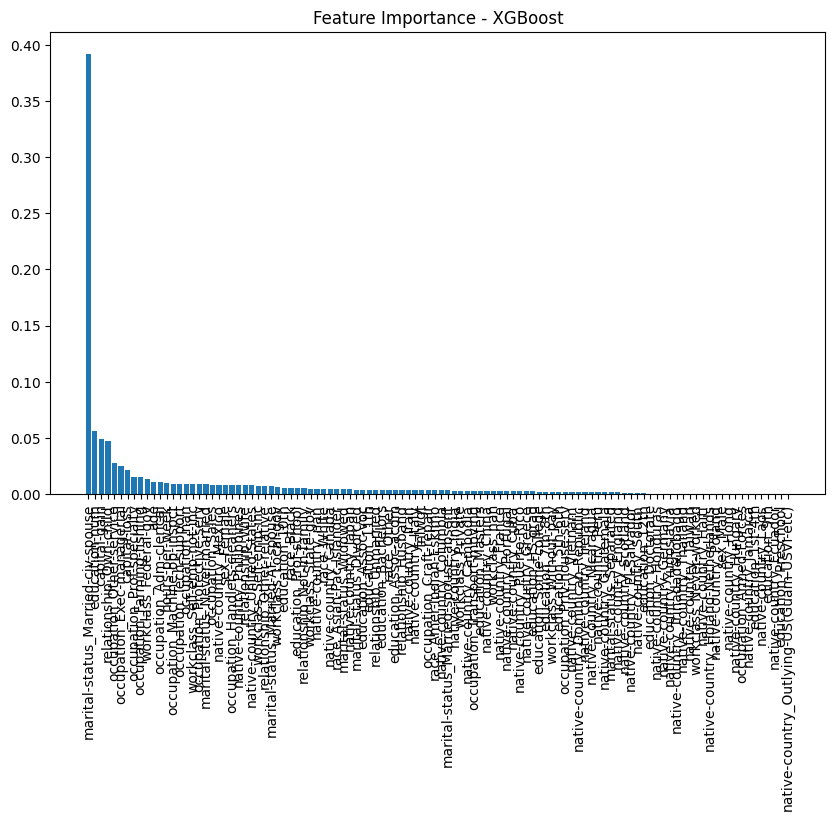

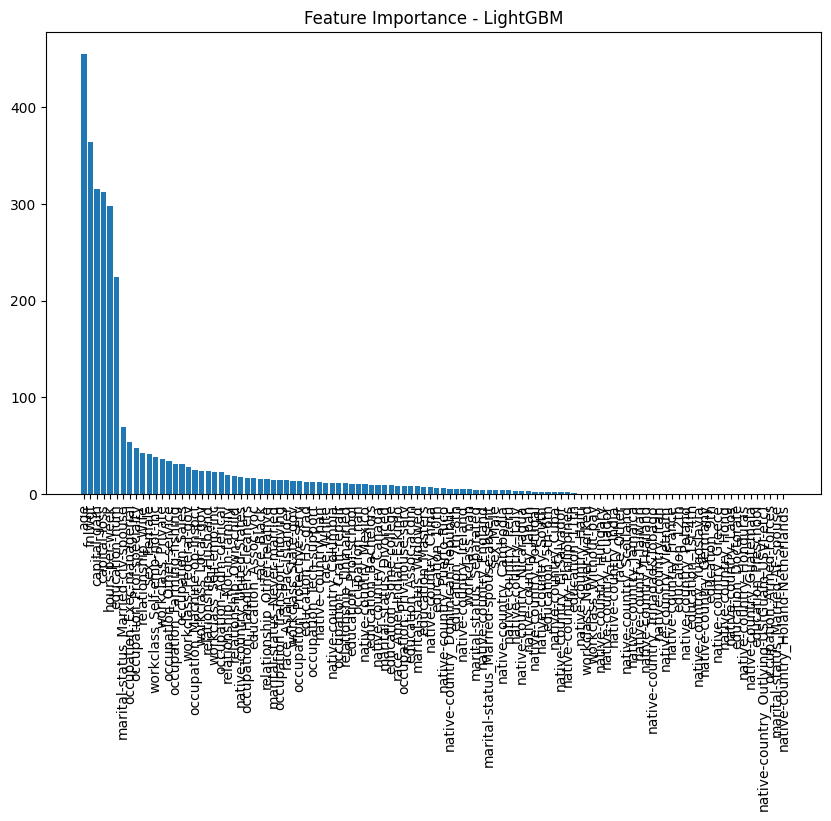

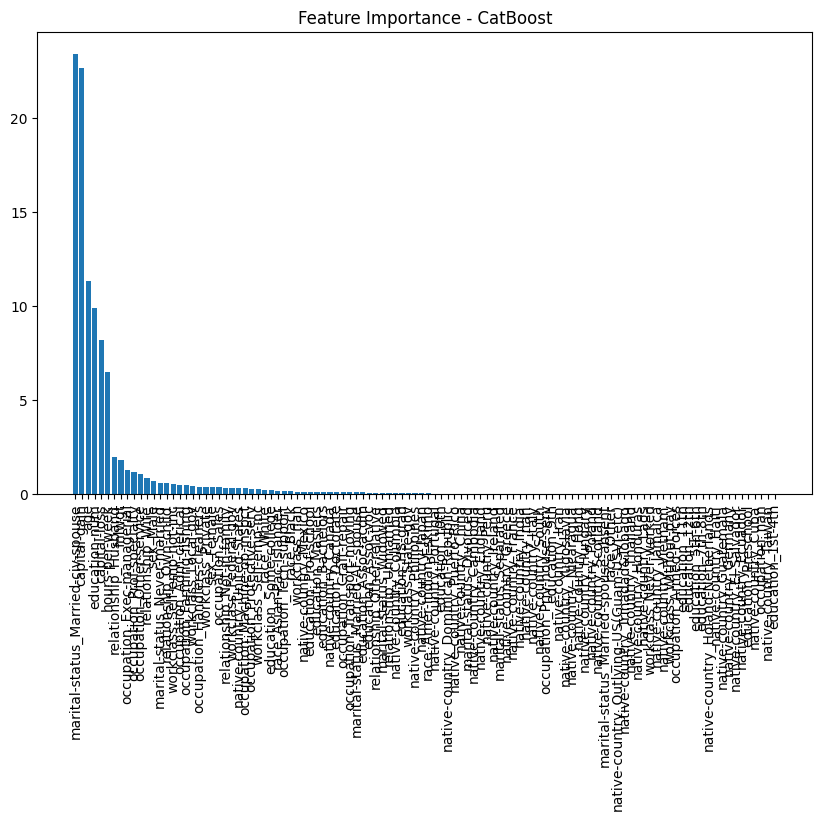

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Obtener el nombre de las columnas procesadas (después del preprocesamiento)
processed_columns = np.hstack([numeric_cols, preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)])

# Obtener los mejores modelos después de la búsqueda de hiperparámetros
xgb_best = xgb_grid.best_estimator_.named_steps['classifier']
lgbm_best = lgbm_grid.best_estimator_.named_steps['classifier']
cat_best = cat_grid.best_estimator_.named_steps['classifier']

# XGBoost: Importancia de características
xgb_importance = xgb_best.feature_importances_

# LightGBM: Importancia de características
lgbm_importance = lgbm_best.feature_importances_

# CatBoost: Importancia de características
cat_importance = cat_best.get_feature_importance()

# Función para mostrar la importancia de características
def plot_feature_importance(importances, model_name, columns):
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(10, 6))
    plt.title(f"Feature Importance - {model_name}")
    plt.bar(range(len(importances)), importances[indices], align='center')
    plt.xticks(range(len(importances)), np.array(columns)[indices], rotation=90)
    plt.show()

# Mostrar importancia de características para cada modelo
plot_feature_importance(xgb_importance, 'XGBoost', processed_columns)
plot_feature_importance(lgbm_importance, 'LightGBM', processed_columns)
plot_feature_importance(cat_importance, 'CatBoost', processed_columns)


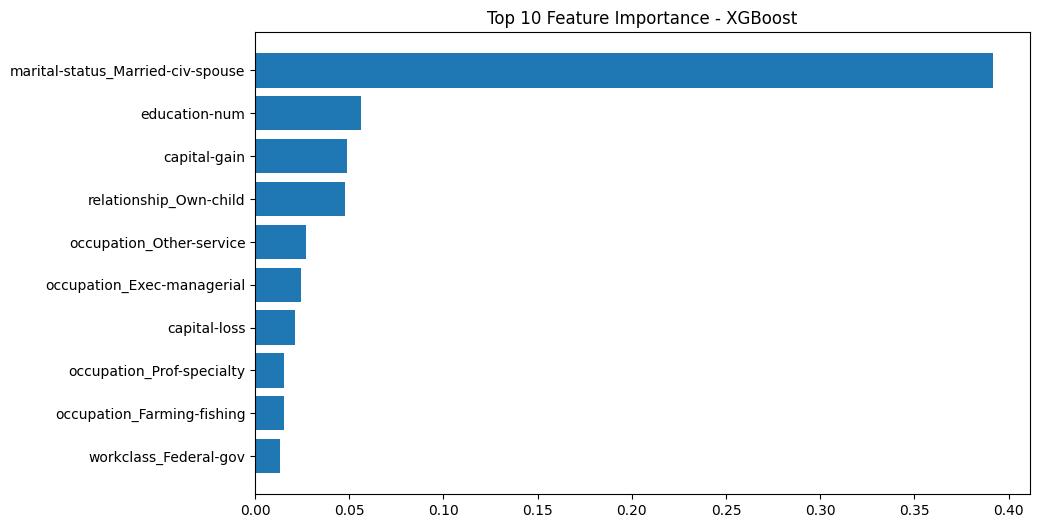

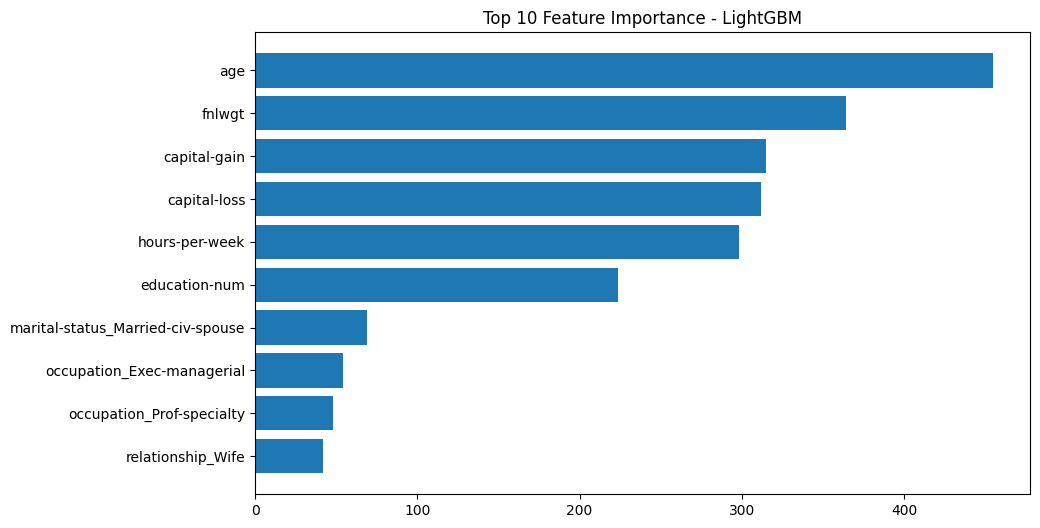

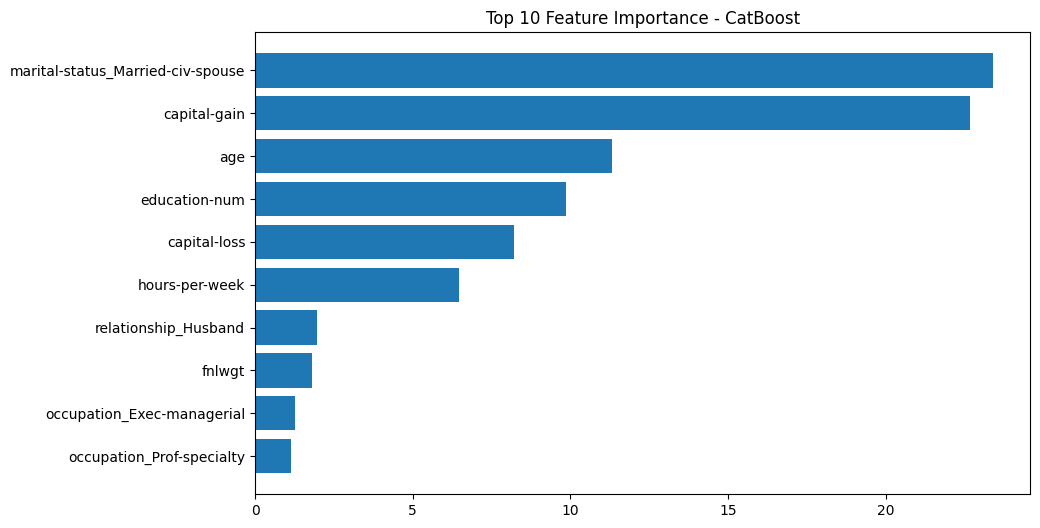

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Función actualizada para mostrar solo las 10 características más importantes con nombres en el eje Y
def plot_feature_importance(importances, model_name, columns):
    # Obtener los 10 índices de las características más importantes
    indices = np.argsort(importances)[::-1][:10]

    # Crear el gráfico de barras horizontal
    plt.figure(figsize=(10, 6))
    plt.title(f"Top 10 Feature Importance - {model_name}")
    plt.barh(range(len(indices)), importances[indices], align='center')

    # Colocar los nombres de las características en el eje Y
    plt.yticks(range(len(indices)), np.array(columns)[indices])
    plt.gca().invert_yaxis()  # Invertir el eje Y para que las características más importantes estén arriba

    plt.show()

# Mostrar la importancia de características para cada modelo
plot_feature_importance(xgb_importance, 'XGBoost', processed_columns)
plot_feature_importance(lgbm_importance, 'LightGBM', processed_columns)
plot_feature_importance(cat_importance, 'CatBoost', processed_columns)



### Interpretación de la importancia de características

- **XGBoost**: El **gain** será la métrica más relevante aquí, indicando cuánto contribuye cada característica a la mejora del modelo. Observaremos que las características que tienen más impacto en la reducción del error estarán en la parte superior.
  
- **LightGBM**: Similar a XGBoost, pero con mayor eficiencia en grandes conjuntos de datos. Las características más importantes según el **gain** nos ayudarán a identificar las variables clave.

- **CatBoost**: CatBoost manejará las características categóricas de manera nativa, y veremos que algunas características categóricas podrían ser más importantes que las numéricas, dependiendo del dataset.

